### SVM Kernals Indepth Intuition Practical Explanation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
 
x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2-x**2)
y=np.hstack([-y,y])
x=np.hstack([x,-x])

In [2]:
x

array([-5.        , -4.8989899 , -4.7979798 , -4.6969697 , -4.5959596 ,
       -4.49494949, -4.39393939, -4.29292929, -4.19191919, -4.09090909,
       -3.98989899, -3.88888889, -3.78787879, -3.68686869, -3.58585859,
       -3.48484848, -3.38383838, -3.28282828, -3.18181818, -3.08080808,
       -2.97979798, -2.87878788, -2.77777778, -2.67676768, -2.57575758,
       -2.47474747, -2.37373737, -2.27272727, -2.17171717, -2.07070707,
       -1.96969697, -1.86868687, -1.76767677, -1.66666667, -1.56565657,
       -1.46464646, -1.36363636, -1.26262626, -1.16161616, -1.06060606,
       -0.95959596, -0.85858586, -0.75757576, -0.65656566, -0.55555556,
       -0.45454545, -0.35353535, -0.25252525, -0.15151515, -0.05050505,
        0.05050505,  0.15151515,  0.25252525,  0.35353535,  0.45454545,
        0.55555556,  0.65656566,  0.75757576,  0.85858586,  0.95959596,
        1.06060606,  1.16161616,  1.26262626,  1.36363636,  1.46464646,
        1.56565657,  1.66666667,  1.76767677,  1.86868687,  1.96

In [3]:
y

array([-8.66025404, -8.71779204, -8.77378994, -8.82827705, -8.88128118,
       -8.93282873, -8.98294476, -9.03165312, -9.07897646, -9.12493632,
       -9.16955321, -9.21284664, -9.25483518, -9.29553652, -9.3349675 ,
       -9.37314414, -9.41008171, -9.44579475, -9.4802971 , -9.51360192,
       -9.54572176, -9.57666854, -9.60645359, -9.63508769, -9.66258107,
       -9.68894344, -9.714184  , -9.73831149, -9.76133416, -9.7832598 ,
       -9.80409577, -9.82384901, -9.84252604, -9.86013297, -9.87667553,
       -9.89215905, -9.90658851, -9.91996849, -9.93230325, -9.94359667,
       -9.9538523 , -9.96307334, -9.97126266, -9.9784228 , -9.98455598,
       -9.98966408, -9.99374868, -9.99681104, -9.99885209, -9.99987246,
       -9.99987246, -9.99885209, -9.99681104, -9.99374868, -9.98966408,
       -9.98455598, -9.9784228 , -9.97126266, -9.96307334, -9.9538523 ,
       -9.94359667, -9.93230325, -9.91996849, -9.90658851, -9.89215905,
       -9.87667553, -9.86013297, -9.84252604, -9.82384901, -9.80

In [4]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2-x1**2)
y1=np.hstack([-y1,y1])
x1=np.hstack([x1,-x1])

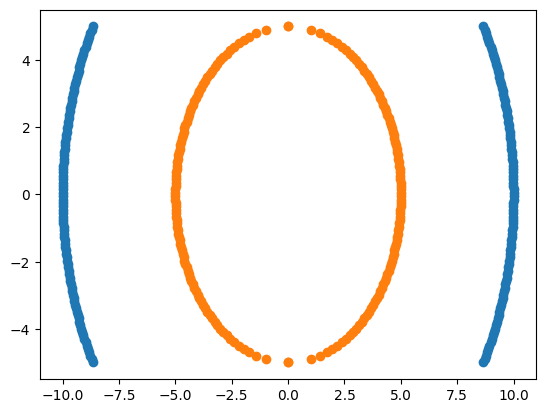

In [5]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [6]:
np.vstack([y,x]).T

array([[-8.66025404, -5.        ],
       [-8.71779204, -4.8989899 ],
       [-8.77378994, -4.7979798 ],
       [-8.82827705, -4.6969697 ],
       [-8.88128118, -4.5959596 ],
       [-8.93282873, -4.49494949],
       [-8.98294476, -4.39393939],
       [-9.03165312, -4.29292929],
       [-9.07897646, -4.19191919],
       [-9.12493632, -4.09090909],
       [-9.16955321, -3.98989899],
       [-9.21284664, -3.88888889],
       [-9.25483518, -3.78787879],
       [-9.29553652, -3.68686869],
       [-9.3349675 , -3.58585859],
       [-9.37314414, -3.48484848],
       [-9.41008171, -3.38383838],
       [-9.44579475, -3.28282828],
       [-9.4802971 , -3.18181818],
       [-9.51360192, -3.08080808],
       [-9.54572176, -2.97979798],
       [-9.57666854, -2.87878788],
       [-9.60645359, -2.77777778],
       [-9.63508769, -2.67676768],
       [-9.66258107, -2.57575758],
       [-9.68894344, -2.47474747],
       [-9.714184  , -2.37373737],
       [-9.73831149, -2.27272727],
       [-9.76133416,

In [7]:
import pandas as pd

In [8]:
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2])
df.head(5)

,X1,X2,Y
0,-8.660254,-5.00000,0
1,-8.717792,-4.89899,0
2,-8.773790,-4.79798,0
3,-8.828277,-4.69697,0
4,-8.881281,-4.59596,0


In [9]:
df.tail()

,X1,X2,Y
195,1.969049,-4.59596,1
196,1.714198,-4.69697,1
197,1.406908,-4.79798,1
198,0.999949,-4.89899,1
199,0.000000,-5.00000,1


In [10]:
### seperating the independnet and dependent features
x=df.iloc[:,:2]
y=df.Y

In [11]:
y

0      0
1      0
2      0
3      0
4      0
      ..
195    1
196    1
197    1
198    1
199    1
Name: Y, Length: 400, dtype: int64

In [12]:
x

,X1,X2
0,-8.660254,-5.00000
1,-8.717792,-4.89899
2,-8.773790,-4.79798
3,-8.828277,-4.69697
4,-8.881281,-4.59596
...,...,...
195,1.969049,-4.59596
196,1.714198,-4.69697
197,1.406908,-4.79798
198,0.999949,-4.89899


In [13]:
## spliiting data for the tests
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=10)

In [14]:
### applying the polynomial kernel
df['X1_square']=df['X1']**2
df['X2_sqaure']=df['X2']**2
df['X1*X2']=(df['X1']*df['X2'])
df.head()

,X1,X2,Y,X1_square,X2_sqaure,X1*X2
0,-8.660254,-5.00000,0,75.000000,25.000000,43.301270
1,-8.717792,-4.89899,0,75.999898,24.000102,42.708375
2,-8.773790,-4.79798,0,76.979390,23.020610,42.096467
3,-8.828277,-4.69697,0,77.938476,22.061524,41.466150
4,-8.881281,-4.59596,0,78.877155,21.122845,40.818009


In [15]:
## independent features and dependent features
x=df[['X1','X2','X1_square','X2_sqaure','X1*X2']]
y=df['Y']

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [17]:
x_train

,X1,X2,X1_square,X2_sqaure,X1*X2
50,-4.999745,0.050505,24.997449,0.002551,-0.252512
63,-9.906589,1.363636,98.140496,1.859504,-13.508984
112,3.263736,3.787879,10.651974,14.348026,12.362637
159,9.953852,-0.959596,99.079176,0.920824,-9.551676
83,-3.680983,3.383838,13.549638,11.450362,-12.455852
...,...,...,...,...,...
123,4.223140,2.676768,17.834915,7.165085,11.304366
192,9.031653,-4.292929,81.570758,18.429242,-38.772248
117,9.445795,3.282828,89.223038,10.776962,31.008922
47,-9.996811,-0.252525,99.936231,0.063769,2.524447


In [18]:
!pip install nbformat --upgrade

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/7 [fastjsonschema]
   ---------------------------------------- 0/7 [fastjsonschema]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------- ----------------- 4/7 [jsonschema-specifications]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ------------

In [19]:
import plotly.express as px
fig=px.scatter_3d(df,x='X1',y='X2',z='X1*X2',color='Y')
fig.show()

In [21]:
fig=px.scatter_3d(df,x='X1_square',y='X2_sqaure',z='X1*X2',color='Y')
fig.show()


In [23]:
from  sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel="linear")
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
accuracy_score(y_test,y_pred)

1.0